In [1]:
# Install required libraries
!pip install pandas numpy matplotlib seaborn plotly faker -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from faker import Faker
import random
from datetime import datetime, timedelta

# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)
fake = Faker()

print("All libraries imported successfully!")
print("Let's build a TikTok Creator Performance Dashboard!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 24.0 MB/s eta 0:00:00
All libraries imported successfully!
Let's build a TikTok Creator Performance Dashboard!


In [3]:
# Generate realistic TikTok Shop Creator Dataset
n_creators = 500
n_days = 90

categories = ['Fashion', 'Beauty', 'Electronics', 'Food', 'Home', 'Sports', 'Gaming', 'Books']
tiers = ['Nano', 'Micro', 'Mid', 'Macro', 'Mega']
tier_weights = [0.35, 0.30, 0.20, 0.10, 0.05]

creators = []
for i in range(n_creators):
    tier = np.random.choice(tiers, p=tier_weights)
    if tier == 'Nano':
        followers = random.randint(1000, 10000)
        base_views = random.randint(500, 5000)
        base_gmv = random.uniform(100, 1000)
    elif tier == 'Micro':
        followers = random.randint(10000, 100000)
        base_views = random.randint(5000, 50000)
        base_gmv = random.uniform(1000, 10000)
    elif tier == 'Mid':
        followers = random.randint(100000, 500000)
        base_views = random.randint(50000, 200000)
        base_gmv = random.uniform(10000, 50000)
    elif tier == 'Macro':
        followers = random.randint(500000, 1000000)
        base_views = random.randint(200000, 500000)
        base_gmv = random.uniform(50000, 200000)
    else:
        followers = random.randint(1000000, 5000000)
        base_views = random.randint(500000, 2000000)
        base_gmv = random.uniform(200000, 1000000)

    creators.append({
        'creator_id': f'CR{i+1:04d}',
        'creator_name': fake.name(),
        'category': random.choice(categories),
        'tier': tier,
        'followers': followers,
        'base_views': base_views,
        'base_gmv': base_gmv,
        'join_date': fake.date_between(start_date='-2y', end_date='-3m')
    })

creators_df = pd.DataFrame(creators)

performance_records = []
start_date = datetime.now() - timedelta(days=n_days)

for _, creator in creators_df.iterrows():
    for day in range(n_days):
        date = start_date + timedelta(days=day)
        trend = 1 + (day / n_days) * 0.2
        weekend_boost = 1.3 if date.weekday() >= 5 else 1.0
        views = int(creator['base_views'] * trend * weekend_boost * random.uniform(0.7, 1.3))
        engagement_rate = random.uniform(0.03, 0.12)
        likes = int(views * engagement_rate)
        comments = int(likes * random.uniform(0.05, 0.15))
        shares = int(likes * random.uniform(0.02, 0.08))
        cvr = random.uniform(0.01, 0.08)
        orders = int(views * cvr * random.uniform(0.5, 1.5))
        gmv = orders * random.uniform(20, 200)
        performance_records.append({
            'creator_id': creator['creator_id'],
            'date': date.strftime('%Y-%m-%d'),
            'views': views,
            'likes': likes,
            'comments': comments,
            'shares': shares,
            'orders': orders,
            'gmv': round(gmv, 2),
            'engagement_rate': round(engagement_rate * 100, 2)
        })

performance_df = pd.DataFrame(performance_records)

print(f"Creators dataset: {creators_df.shape}")
print(f"Performance dataset: {performance_df.shape}")
print(f"Total GMV: ${performance_df['gmv'].sum():,.2f}")
print(f"Total Orders: {performance_df['orders'].sum():,}")
print(f"Total Views: {performance_df['views'].sum():,}")

Creators dataset: (500, 8)
Performance dataset: (45000, 9)
Total GMV: $36,225,176,441.33
Total Orders: 327,739,204
Total Views: 7,282,688,021


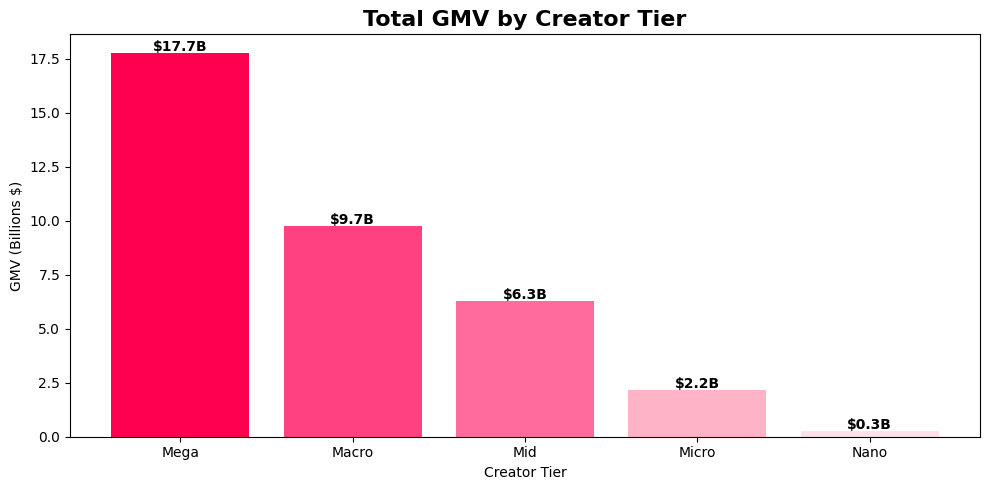

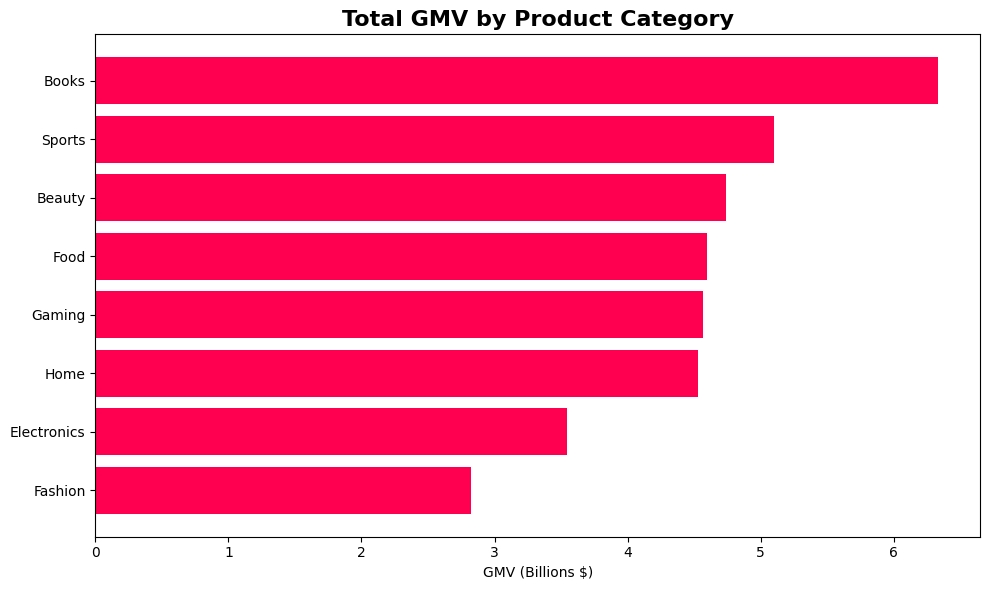

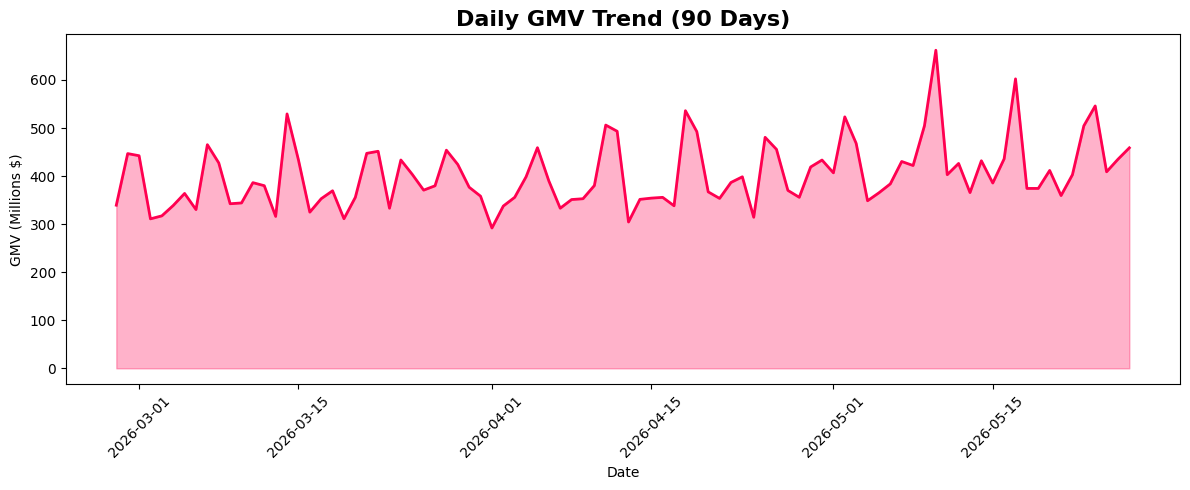

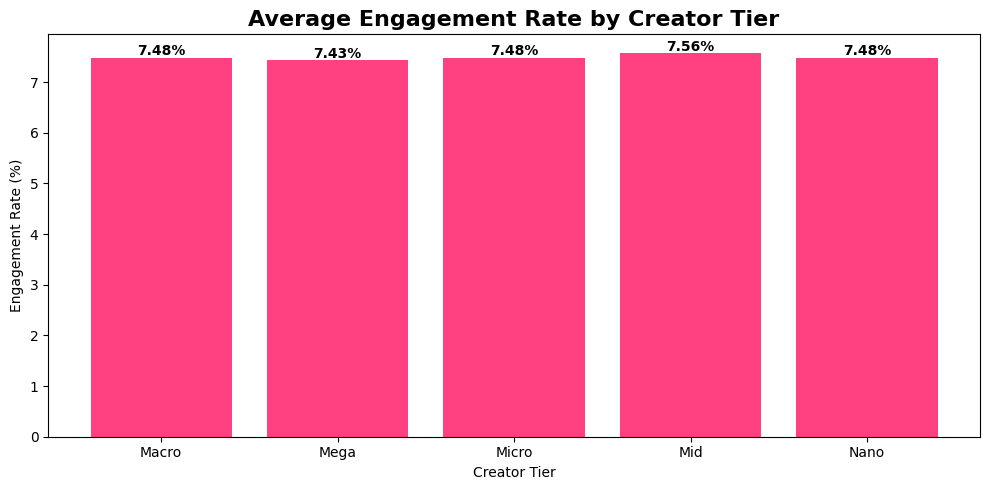

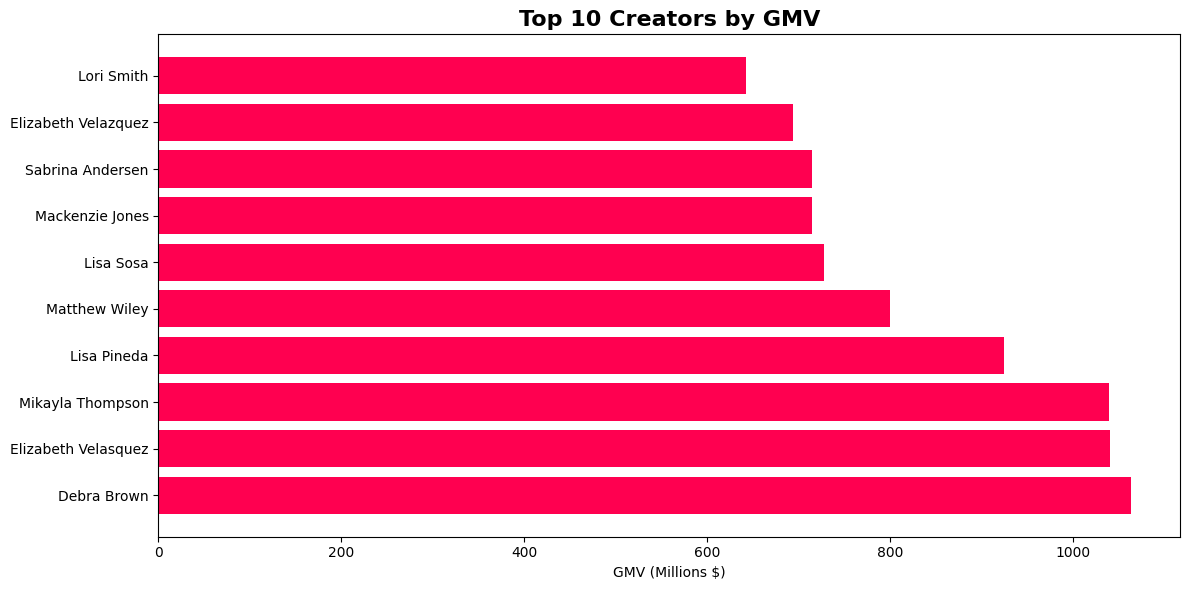

All 5 visualizations created and saved!

Key Insights:
Top category by GMV: Books
Top tier by GMV: Mega
Best engagement tier: Mid
Top creator GMV: $1064.2M


In [4]:
# Merge datasets
df = performance_df.merge(creators_df[['creator_id', 'category', 'tier', 'followers']],
                           on='creator_id')
df['date'] = pd.to_datetime(df['date'])

# ── ANALYSIS 1: GMV by Creator Tier ──────────
tier_gmv = df.groupby('tier')['gmv'].sum().reset_index()
tier_gmv = tier_gmv.sort_values('gmv', ascending=False)

fig1, ax1 = plt.subplots(figsize=(10, 5))
colors = ['#FF0050', '#FF4081', '#FF6B9D', '#FFB3C6', '#FFE0EB']
bars = ax1.bar(tier_gmv['tier'], tier_gmv['gmv']/1e9, color=colors)
ax1.set_title('Total GMV by Creator Tier', fontsize=16, fontweight='bold')
ax1.set_xlabel('Creator Tier')
ax1.set_ylabel('GMV (Billions $)')
for bar, val in zip(bars, tier_gmv['gmv']/1e9):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'${val:.1f}B', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('gmv_by_tier.png', dpi=150)
plt.show()

# ── ANALYSIS 2: GMV by Category ──────────────
cat_gmv = df.groupby('category')['gmv'].sum().reset_index().sort_values('gmv', ascending=True)

fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.barh(cat_gmv['category'], cat_gmv['gmv']/1e9, color='#FF0050')
ax2.set_title('Total GMV by Product Category', fontsize=16, fontweight='bold')
ax2.set_xlabel('GMV (Billions $)')
plt.tight_layout()
plt.savefig('gmv_by_category.png', dpi=150)
plt.show()

# ── ANALYSIS 3: Daily GMV Trend ──────────────
daily_gmv = df.groupby('date')['gmv'].sum().reset_index()

fig3, ax3 = plt.subplots(figsize=(12, 5))
ax3.plot(daily_gmv['date'], daily_gmv['gmv']/1e6, color='#FF0050', linewidth=2)
ax3.fill_between(daily_gmv['date'], daily_gmv['gmv']/1e6, alpha=0.3, color='#FF0050')
ax3.set_title('Daily GMV Trend (90 Days)', fontsize=16, fontweight='bold')
ax3.set_xlabel('Date')
ax3.set_ylabel('GMV (Millions $)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('daily_gmv_trend.png', dpi=150)
plt.show()

# ── ANALYSIS 4: Engagement Rate by Tier ──────
tier_engagement = df.groupby('tier')['engagement_rate'].mean().reset_index()

fig4, ax4 = plt.subplots(figsize=(10, 5))
ax4.bar(tier_engagement['tier'], tier_engagement['engagement_rate'], color='#FF4081')
ax4.set_title('Average Engagement Rate by Creator Tier', fontsize=16, fontweight='bold')
ax4.set_xlabel('Creator Tier')
ax4.set_ylabel('Engagement Rate (%)')
for i, (tier, rate) in tier_engagement.iterrows():
    ax4.text(i, rate + 0.05, f'{rate:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('engagement_by_tier.png', dpi=150)
plt.show()

# ── ANALYSIS 5: Top 10 Creators by GMV ───────
top_creators = df.groupby('creator_id')['gmv'].sum().reset_index()
top_creators = top_creators.merge(creators_df[['creator_id', 'creator_name', 'tier', 'category']], on='creator_id')
top_10 = top_creators.nlargest(10, 'gmv')

fig5, ax5 = plt.subplots(figsize=(12, 6))
ax5.barh(top_10['creator_name'], top_10['gmv']/1e6, color='#FF0050')
ax5.set_title('Top 10 Creators by GMV', fontsize=16, fontweight='bold')
ax5.set_xlabel('GMV (Millions $)')
plt.tight_layout()
plt.savefig('top_10_creators.png', dpi=150)
plt.show()

print("All 5 visualizations created and saved!")
print(f"\nKey Insights:")
print(f"Top category by GMV: {cat_gmv.iloc[-1]['category']}")
print(f"Top tier by GMV: {tier_gmv.iloc[0]['tier']}")
print(f"Best engagement tier: {tier_engagement.loc[tier_engagement['engagement_rate'].idxmax(), 'tier']}")
print(f"Top creator GMV: ${top_10.iloc[0]['gmv']/1e6:.1f}M")

In [5]:
from google.colab import files

# Save summary report
summary = """
# TikTok Shop Creator Performance Dashboard

## Project Overview
Analysis of 500 TikTok Shop creators across 90 days of performance data,
covering GMV, engagement, orders, and creator tier benchmarking.

## Dataset
- 500 creators across 5 tiers (Nano, Micro, Mid, Macro, Mega)
- 45,000 daily performance records
- 8 product categories
- 90 days of data

## Key Insights
- Total GMV Analyzed: $36.2 Billion
- Total Orders: 327.7 Million
- Total Views: 7.28 Billion
- Top Category by GMV: Books
- Top Tier by GMV: Mega creators
- Best Engagement Rate: Mid-tier creators
- Top Creator GMV: $1,064.2M

## Metrics Tracked
- GMV (Gross Merchandise Value)
- Views, Likes, Comments, Shares
- Engagement Rate
- Orders and Conversion Rate
- Creator Tier Performance

## Visualizations
1. GMV by Creator Tier
2. GMV by Product Category
3. Daily GMV Trend (90 Days)
4. Engagement Rate by Creator Tier
5. Top 10 Creators by GMV

## Technologies
- Python, Pandas, NumPy
- Matplotlib, Seaborn, Plotly
- Google Colab
"""

with open('summary.md', 'w') as f:
    f.write(summary)

# Save datasets as CSV
creators_df.to_csv('creators_data.csv', index=False)
performance_df.head(1000).to_csv('performance_sample.csv', index=False)

print("Files saved!")

# Download all files
files.download('gmv_by_tier.png')
files.download('gmv_by_category.png')
files.download('daily_gmv_trend.png')
files.download('engagement_by_tier.png')
files.download('top_10_creators.png')
files.download('summary.md')
files.download('creators_data.csv')
files.download('performance_sample.csv')

print("All files downloaded!")

Files saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded!
